## Class distribution for train/validation/test

This creates dataset instances with the same data settings used in training scripts and plots class counts for each split.

In [29]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.datasets.speech_commands.config import CANONICAL
from thesis_project.utils.paths import get_data_dir



# Match data setup used during training scripts
train_kwargs = dict(
    keyword_list=CANONICAL,
    use_unknown=True,
    use_silence=True,
    upsample=False,
    add_noise=True,
    noise_prob=0.8,
    snr=(-5, 15),
)

eval_kwargs = dict(
    keyword_list=CANONICAL,
    use_unknown=True,
    use_silence=True,
    upsample=False,
    add_noise=True,
    noise_prob=1.0,
    snr=float("inf"),
)

data_dir = get_data_dir()


In [30]:



train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **train_kwargs)
val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **eval_kwargs)
test_set = SpeechCommandsGoogle(root=str(data_dir), subset="testing", download=True, **eval_kwargs)

def get_label_counts(ds):
    # ds.label_counts already reflects the effective dataset view used for loading
    return Counter(ds.label_counts)

counts = {
    "train": get_label_counts(train_set),
    "validation": get_label_counts(val_set),
    "test": get_label_counts(test_set),
}

all_labels = sorted(set().union(*[c.keys() for c in counts.values()]))
df = pd.DataFrame({split: [counts[split].get(lbl, 0) for lbl in all_labels] for split in counts}, index=all_labels)
df = df.reset_index().rename(columns={'index': 'class'})

Adding noise: 100%|██████████| 4924/4924 [00:20<00:00, 235.65sample/s]


,class,train,validation,test
0,SILENCE,3228,406,425
1,UNKNOWN,3228,406,425
2,down,3134,377,406
3,go,3106,372,402
4,left,3037,352,412
5,no,3130,406,405
6,off,2970,373,402
7,on,3086,363,396
8,right,3019,363,396
9,stop,3111,350,411


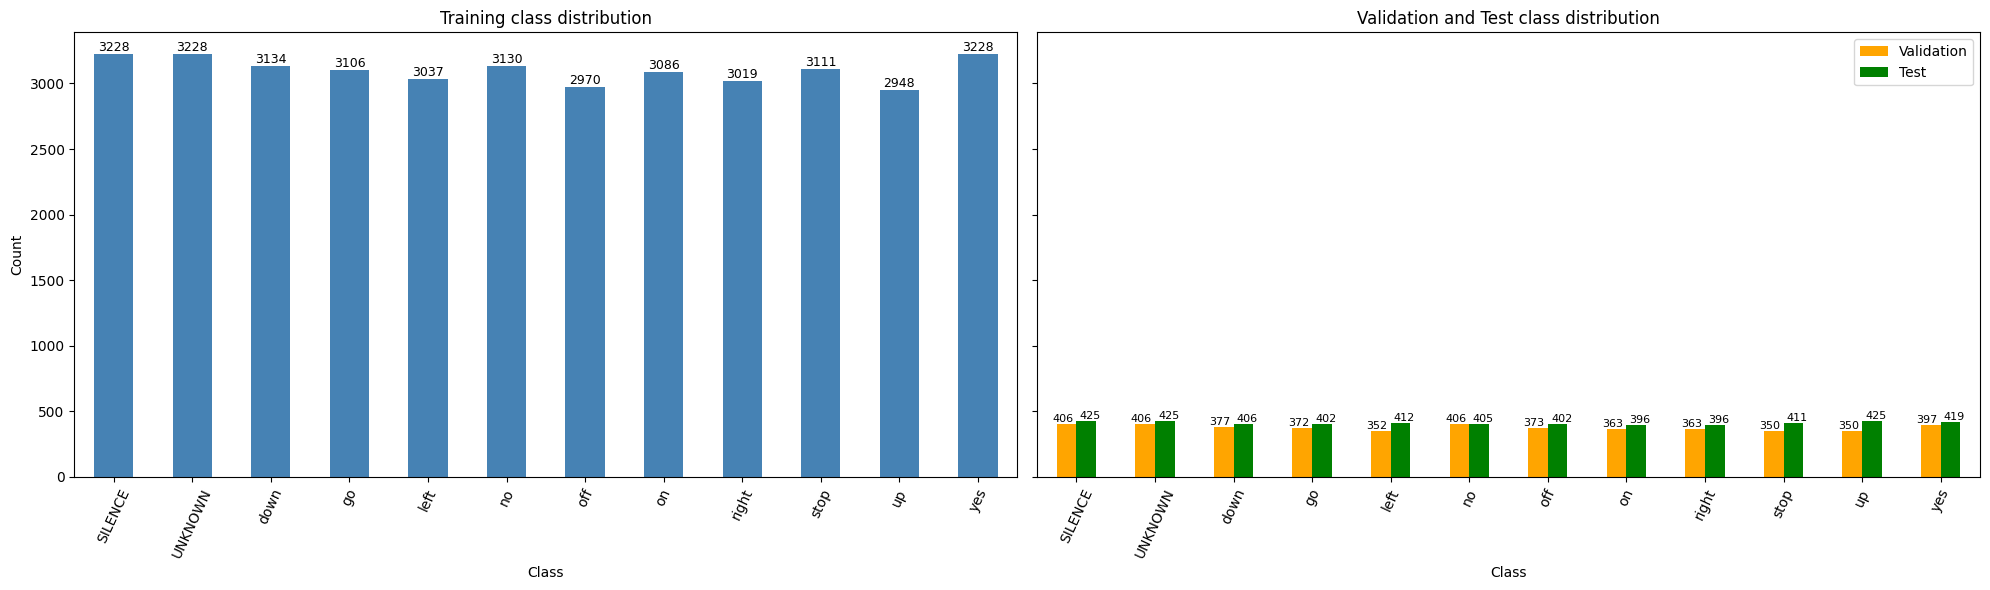

In [31]:
display(df)

# Create two separate plots with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Plot 1: Training only
train_data = df.set_index('class')['train']
bars1 = train_data.plot(kind="bar", ax=ax1, color='steelblue')
ax1.set_title("Training class distribution")
ax1.set_xlabel("Class")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=65)

# Add values on top of bars
for i, (idx, val) in enumerate(train_data.items()):
    ax1.text(i, val, str(val), ha='center', va='bottom', fontsize=9)

# Plot 2: Validation and Test
val_test_data = df.set_index('class')[['validation', 'test']]
bars2 = val_test_data.plot(kind="bar", ax=ax2, color=['orange', 'green'])
ax2.set_title("Validation and Test class distribution")
ax2.set_xlabel("Class")
ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=65)
ax2.legend(["Validation", "Test"])

# Add values on top of bars for validation and test
x_positions = range(len(val_test_data))
bar_width = 0.35
for i, idx in enumerate(val_test_data.index):
    val_val = val_test_data.loc[idx, 'validation']
    test_val = val_test_data.loc[idx, 'test']
    ax2.text(i - bar_width/2, val_val, str(val_val), ha='center', va='bottom', fontsize=8)
    ax2.text(i + bar_width/2, test_val, str(test_val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [32]:
# Print smallest and biggest class for each split
for split in ["train", "validation", "test"]:
    split_data = df.set_index('class')[split]
    min_class = split_data.idxmin()
    max_class = split_data.idxmax()
    min_count = split_data.min()
    max_count = split_data.max()
    total_count = split_data.sum()
    
    print(f"{split.capitalize()}:")
    print(f"  Total size:  {total_count} samples")
    print(f"  Smallest:    {min_class} ({min_count} samples)")
    print(f"  Largest:     {max_class} ({max_count} samples)")
    print()

Train:
  Total size:  37225 samples
  Smallest:    up (2948 samples)
  Largest:     SILENCE (3228 samples)

Validation:
  Total size:  4515 samples
  Smallest:    stop (350 samples)
  Largest:     SILENCE (406 samples)

Test:
  Total size:  4924 samples
  Smallest:    on (396 samples)
  Largest:     SILENCE (425 samples)



### Noise Augmentation Visualization

In [33]:
## Visualize first validation sample with different SNR levels

import numpy as np
val_set_for_audio_viz = SpeechCommandsGoogle(
        root=str(data_dir),
        subset="validation",
        download=False,
        keyword_list=CANONICAL,
        use_unknown=True,
        use_silence=True,
        upsample=False,
        add_noise=True,
        noise_prob=1.0,
    )

Adding noise: 100%|██████████| 4515/4515 [00:15<00:00, 300.18sample/s]


In [34]:
# Create validation sets with different SNR values and get first sample from each
snr_values = [-5, 0, 5, 10, 15, float('inf')]
samples_dict = {}
for snr_val in snr_values:
    val_set.set_snr(snr_val)
    
    # Get first sample
    waveform, label, metadata = val_set[4]
    #print(metadata)
    samples_dict[snr_val] = waveform, label, metadata
    
    if snr_val == float('inf'):
        title = "Clean (no noise)"
    else:
        title = f"SNR = {snr_val} dB"
    
   # print(f"{title:20} | Path: {metadata['path']:30} | Label: {label}")

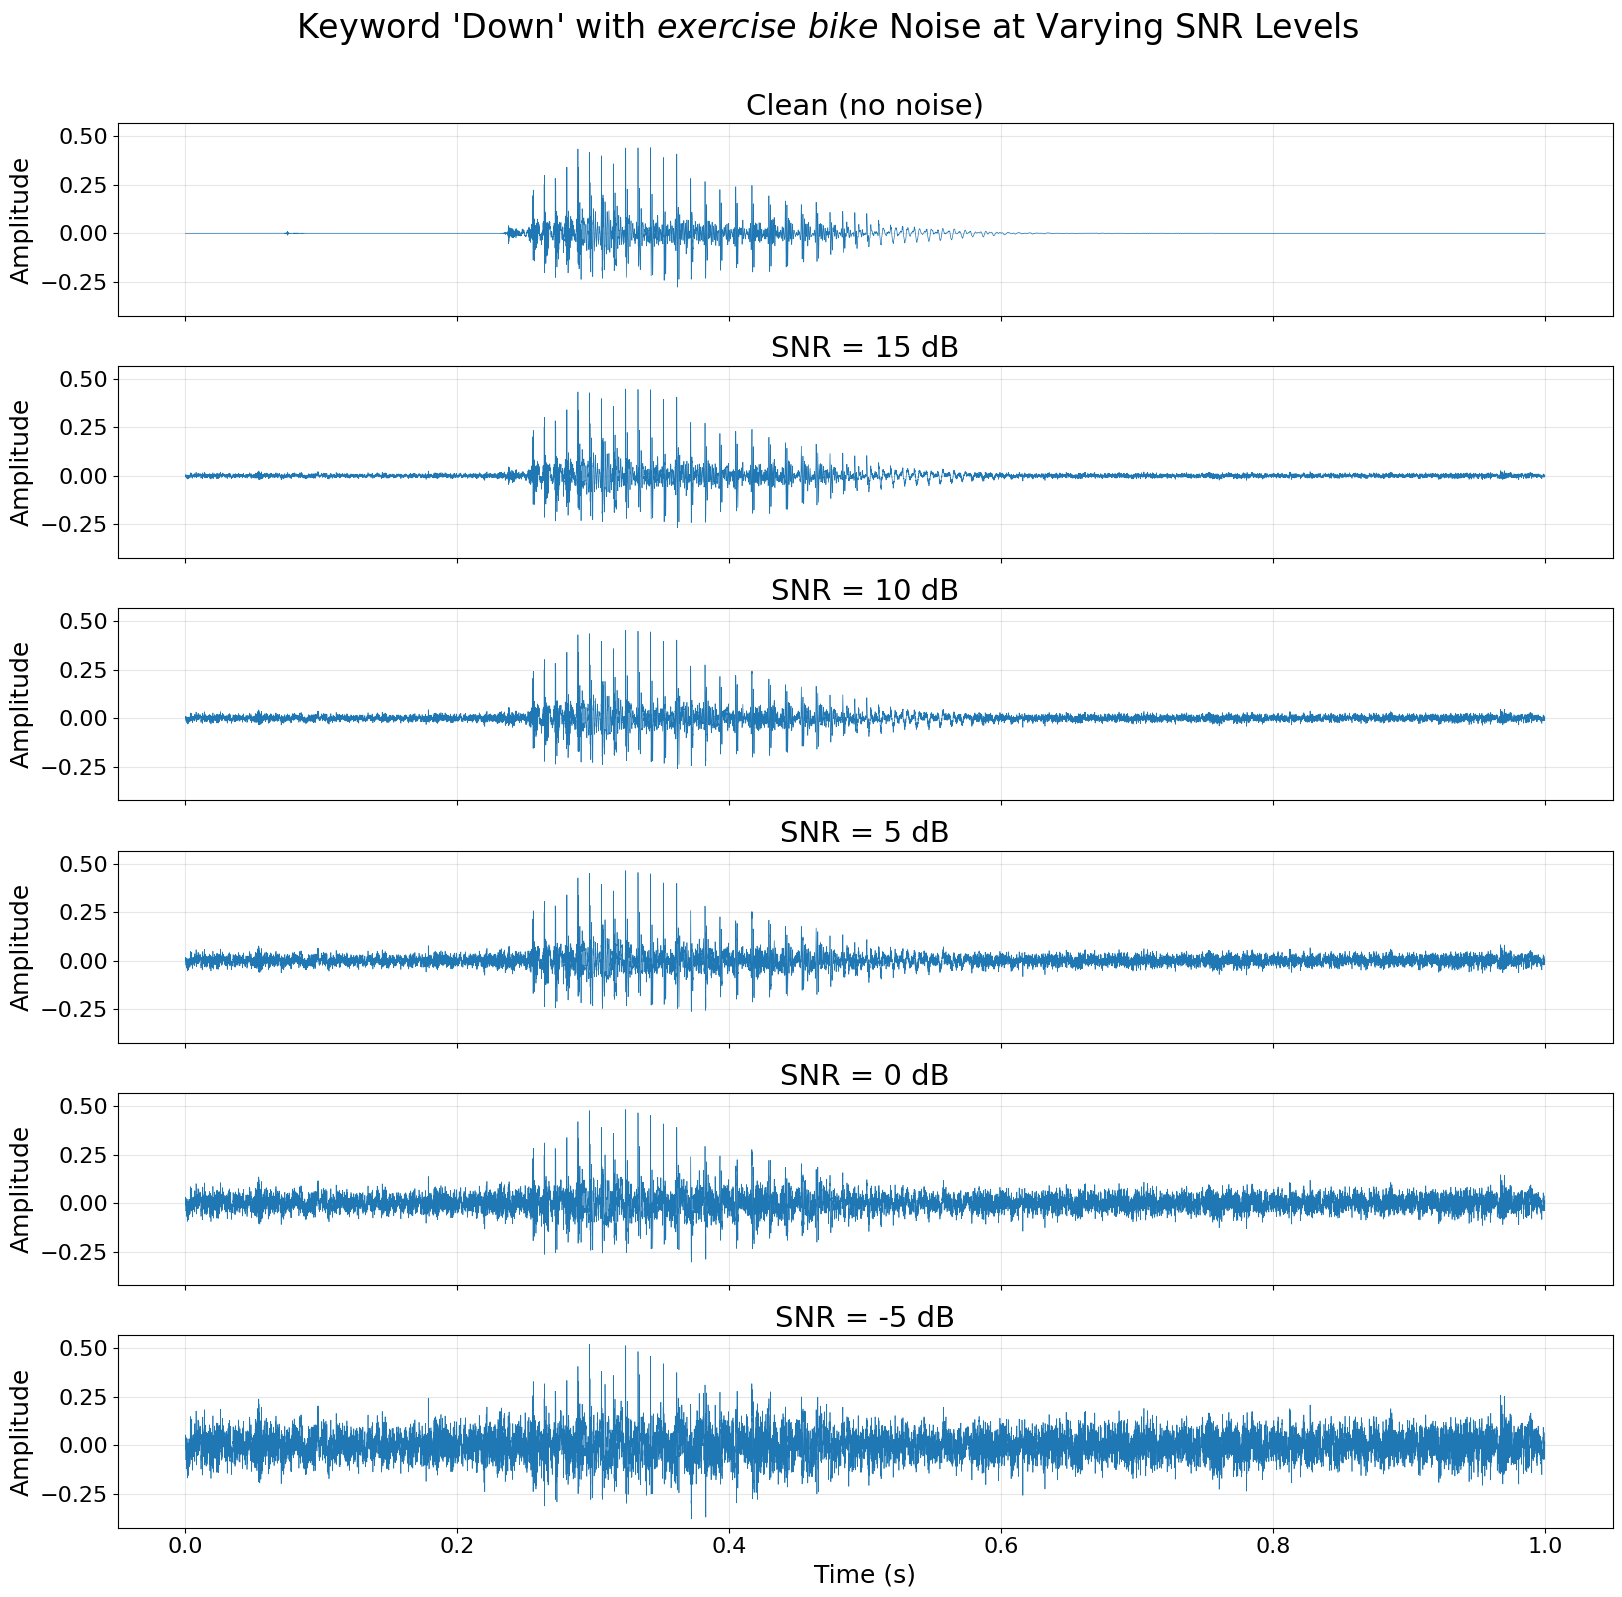

In [51]:
# Plot waveforms for each SNR level
fig, axes = plt.subplots(6, 1, figsize=(16, 16), sharex=True, sharey=True)
axes = axes.flatten()

# Clean first, then descending SNR
snr_plot_order = [float('inf'), 15, 10, 5, 0, -5]

# Main title: italic noise label without underscores
_, ref_label, ref_metadata = samples_dict[snr_plot_order[0]]
noise_label = ref_metadata.get('noise_type', 'N/A').replace('_', ' ')
noise_label_math = noise_label.replace(' ', r'\ ')
fig.suptitle(
    rf"Keyword 'Down' with $\it{{{noise_label_math}}}$ Noise at Varying SNR Levels",
    fontsize=24,
    y=0.995,
 )

# Compute one shared y-axis range for all subplots
y_mins, y_maxs = [], []
for snr_val in snr_plot_order:
    wav_all = samples_dict[snr_val][0].squeeze()
    y_mins.append(float(wav_all.min()))
    y_maxs.append(float(wav_all.max()))
y_min, y_max = min(y_mins), max(y_maxs)
y_pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
shared_ylim = (y_min - y_pad, y_max + y_pad)

for idx, snr_val in enumerate(snr_plot_order):
    ax = axes[idx]
    waveform, label, metadata = samples_dict[snr_val]
    wav = waveform.squeeze()  # Remove channel dimension if present
    time_axis = np.arange(wav.shape[0]) / 16000  # 16 kHz sample rate
    
    if snr_val == float('inf'):
        snr_str = "Clean (no noise)"
    else:
        snr_str = f"SNR = {snr_val} dB"
    
    ax.plot(time_axis, wav.numpy(), linewidth=0.5)
    ax.set_ylim(shared_ylim)
    ax.set_title(snr_str, fontsize=21)
    ax.set_ylabel("Amplitude", fontsize=18)
    ax.tick_params(axis='y', which='major', labelsize=16)
    ax.grid(True, alpha=0.3)

    # Show x tick labels only on the last subplot
    if idx < len(snr_plot_order) - 1:
        ax.tick_params(axis='x', which='both', labelbottom=False)
    else:
        ax.set_xlabel("Time (s)", fontsize=18)
        ax.tick_params(axis='x', which='major', labelsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/noise_viz.png", dpi=500, bbox_inches="tight")
plt.show()